In [20]:
# Matrix Libraries
import pandas as pd
import numpy as np

# Machine Learning Libraries
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Data Preprocessing Libraries
import missingno as msno

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

import sys

In [21]:
# Load the data
Td = pd.read_csv('TelecomCustomerChurn.csv')

# **Telecom Customer Churn Prediction**

## Introduction

In this project, we aim to predict customer churn for a telecom company. Customer churn refers to the phenomenon where customers stop using a company's services. Predicting churn is crucial for businesses as it helps them take proactive measures to retain customers and improve their services.

## Dataset

The dataset used in this project is the "Telecom Customer Churn" dataset. It contains information about 7043 customers, including their demographics, account information, and services they have subscribed to. The dataset has 21 columns, each representing a different feature of the customer.

### Features

- `customerID`: Unique identifier for each customer.
- `Gender`: Gender of the customer (Male/Female).
- `SeniorCitizen`: Indicates if the customer is a senior citizen (1) or not (0).
- `Partner`: Indicates if the customer has a partner (Yes/No).
- `Dependents`: Indicates if the customer has dependents (Yes/No).
- `Tenure`: Number of months the customer has stayed with the company.
- `PhoneService`: Indicates if the customer has phone service (Yes/No).
- `MultipleLines`: Indicates if the customer has multiple lines (Yes/No).
- `InternetService`: Type of internet service the customer has (DSL/Fiber optic/No).
- `OnlineSecurity`: Indicates if the customer has online security service (Yes/No).
- `OnlineBackup`: Indicates if the customer has online backup service (Yes/No).
- `DeviceProtection`: Indicates if the customer has device protection service (Yes/No).
- `TechSupport`: Indicates if the customer has tech support service (Yes/No).
- `StreamingTV`: Indicates if the customer has streaming TV service (Yes/No).
- `StreamingMovies`: Indicates if the customer has streaming movies service (Yes/No).
- `Contract`: Type of contract the customer has (Month-to-month/One year/Two year).
- `PaperlessBilling`: Indicates if the customer has paperless billing (Yes/No).
- `PaymentMethod`: Payment method used by the customer (Electronic check/Mailed check/Bank transfer/Credit card).
- `MonthlyCharges`: The amount charged to the customer monthly.
- `TotalCharges`: The total amount charged to the customer.
- `Churn`: Indicates if the customer has churned (Yes/No).

The target variable in this dataset is `Churn`, which we aim to predict using the other features.

## Objective

The objective of this project is to build a machine learning model that can accurately predict whether a customer will churn or not based on their features. This will help the telecom company identify at-risk customers and take necessary actions to retain them.

---

# Data Visualization

In [22]:
Td

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Monthly,Yes,Manual,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Manual,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Manual,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No,DSL,Yes,...,No,No,No,No,Monthly,Yes,Manual,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Monthly,Yes,Manual,74.40,306.6,Yes


In [23]:
Td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


First thing to do is to modify the target column **Churn** with a <code>LableEncoder</code> so that we have numerical values as targets.

In [24]:
le = LabelEncoder()
Td['Churn'] = le.fit_transform(Td['Churn'])

There appear to be no missing values in the dataset based on the `info()` output. However, there's need to investigate further as there might be features with 'NaN' values represented as strings. Additionally, we need to convert the `TotalCharges` column to the `float64` data type for accurate analysis.

In [25]:
for col in Td.columns:
    print(col+':', Td[col].unique())
    print('-'*50)

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
Gender: ['Female' 'Male']
--------------------------------------------------
SeniorCitizen: [0 1]
--------------------------------------------------
Partner: ['Yes' 'No']
--------------------------------------------------
Dependents: ['No' 'Yes']
--------------------------------------------------
Tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService: ['No' 'Yes']
--------------------------------------------------
MultipleLines: ['No' 'Yes']
--------------------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: ['N

In [26]:
Td = Td.drop(columns=['customerID'])
# We will drop the customerID column as it is not useful for our analysis

Last remaing thing to do is convert the <code>TotalCharges</code> column into <code>float64</code>.

In [27]:
# Convert missing values coded as ' ' to '0.0' and convert the column to float
Td['TotalCharges'] = Td['TotalCharges'].replace(' ', '0.0')
Td['TotalCharges'] = Td['TotalCharges'].astype(float)

In [28]:
# Check for missing values coded as ' '
Td[Td ==' '].count()

Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Now it's sure that there are no missing values in our dataset.

### Noise Adding

To better simulate real world experience I will use functions published by the professor to add noise to the dataset.

In [29]:
def add_missing(col, amount):
    X = col.copy()
    size = amount if amount >= 1 else int(len(X) * amount)
    indexes = np.random.choice(len(X), size, replace = False )
    X[indexes] = np.nan
    return X


In [30]:
# Add missing values to some columns
noise_col = ['Gender', 'Partner', 'Tenure', 'MultipleLines', 'InternetService', 'OnlineBackup', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

for col in noise_col:
    if col == 'Gender':
        Td[col] = add_missing(Td[col], 0.5)
    Td[col] = add_missing(Td[col], 0.1)


In [31]:
Td.isnull().sum(axis=0)/Td.shape[0]

Gender              0.552889
SeniorCitizen       0.000000
Partner             0.099957
Dependents          0.000000
Tenure              0.099957
PhoneService        0.000000
MultipleLines       0.099957
InternetService     0.099957
OnlineSecurity      0.000000
OnlineBackup        0.099957
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.099957
PaymentMethod       0.099957
MonthlyCharges      0.099957
TotalCharges        0.099957
Churn               0.000000
dtype: float64

Another way of visualizing missing data is through the <code>missingno</code> library.

<Axes: >

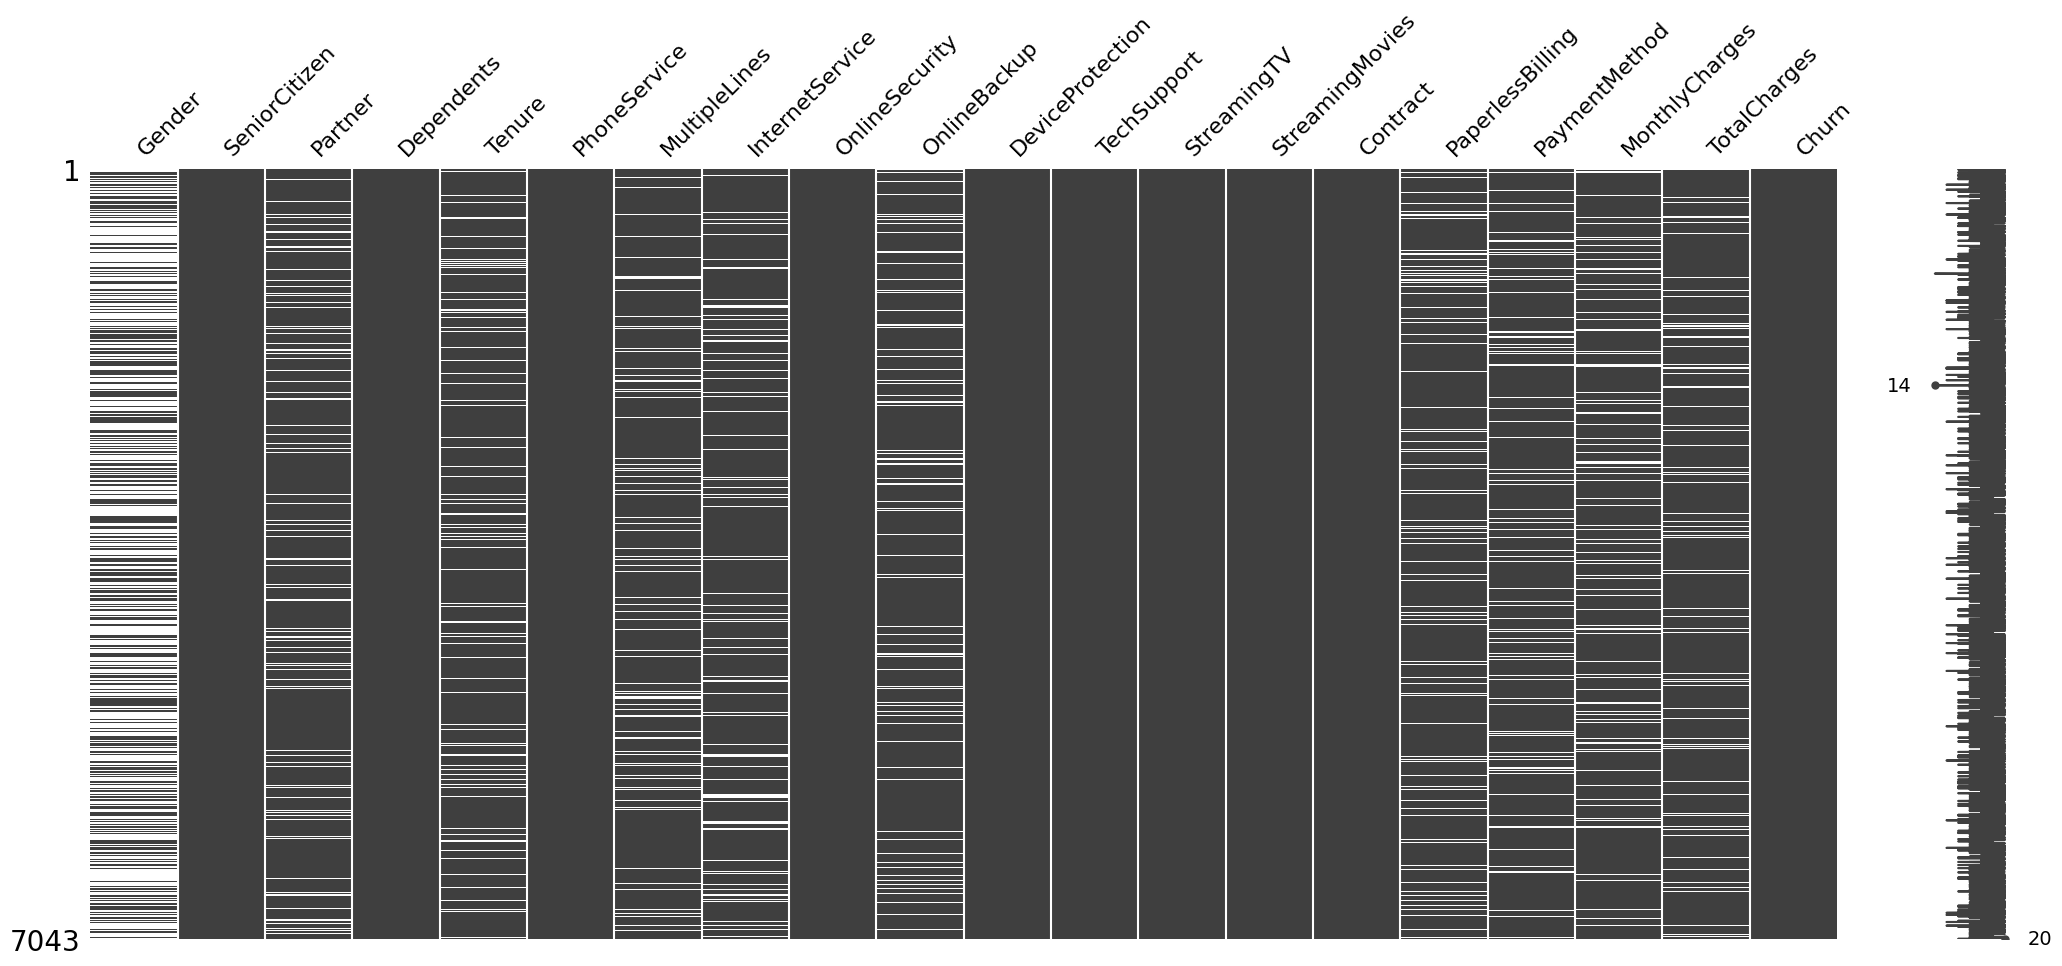

In [32]:
msno.matrix(Td)

# Data Transformation Pipeline

Now that a clear visualization of the dataset in its entirety is found, it's time to define the different pipelines of work that I will apply after the splitting.

### Pipeline1

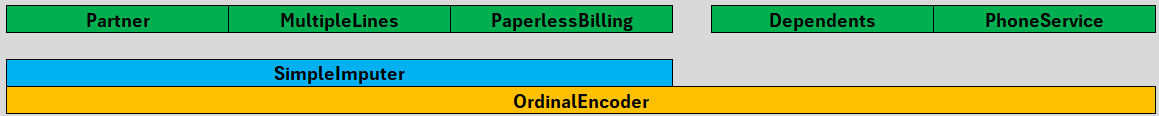

I will address the missing values in the columns: **Partner**, **MultipleLines**, and **PaperlessBilling** using the <code>SimpleImputer</code> from the *Sklearn* library. After imputing the missing values, I will encode the categorical values in these columns with the <code>OrdinalEncoder</code> from the *Sklearn* library.

### Pipeline2

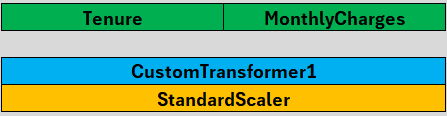

I will address the missing values in the columns **Tenure** and **MonthlyCharges** with a custom transformer and then scale the resulting values with the <code>StandardScaler</code> from the Sklearn library.

### Pipeline3

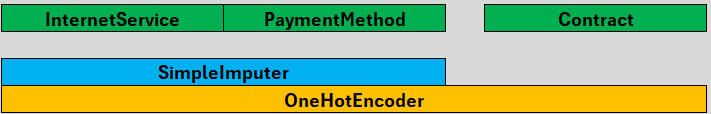

I will address the missing values in the column **InternetService** and **PaymentMethod** with the <code>SimpleImputer</code> from the Sklearn library. Then for all the columns showed I will use the **OneHotEncoder** to map each categorical feature of the column.

### Pipeline4

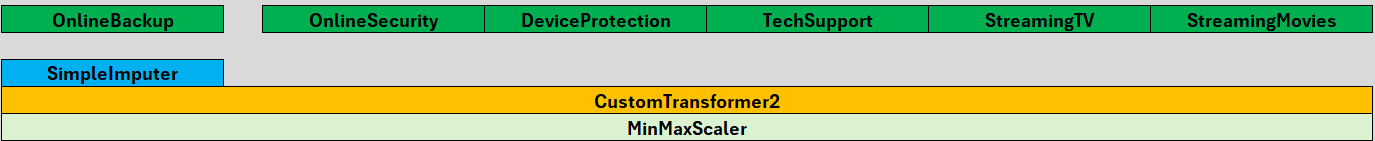

For the last pipeline, I will handle missing values in the **OnlineBackup** column using a <code>SimpleImputer</code>. To reduce complexity and create a more readable dataset, I will combine six columns into one that represents the number of extraservices of the customer. Then with the <code>MinMaxScaler</code> I will normalize the data.

___

The **Gender** column will be dropped due to high percentage of missing values.  
The **TotalCharges** column will be dropped since it's a linear combination of two other columns.  
The **SeniorCitizen** column is not present in any pipeline cause it was already in a good format.  

In [33]:
Td.drop(columns=['Gender'], inplace=True)

### Custom Transformers

The first custom transformer will deal with missing values in the **Tenure** and **MonthlyCharges** columns using the linear relationship that can be found between **Tenure**,**MonthlyCharges** and **TotalCharges**. $$\text{Tenure} = {\text{TotalCharges}\over\text{MonthlyCharges}}$$ After it will drop the **TotalCharges** column to avoid multicollinaerity.

In [34]:
class CustomTransformer1(BaseEstimator, TransformerMixin):
    def __init__(self, tenure_col="Tenure", monthly_col="MonthlyCharges", total_col="TotalCharges"):
        self.tenure_col = tenure_col
        self.monthly_col = monthly_col
        self.total_col = total_col

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):

        ## Fill missing values in the tenure column
        mask = X[self.tenure_col].isna()
        X.loc[mask, self.tenure_col] = (X[self.total_col] / X[self.monthly_col])

        ## Fill missing values in the monthly charges column
        mask = X[self.monthly_col].isna()
        X.loc[mask, self.monthly_col] = (X[self.total_col] / X[self.tenure_col])

        ## Convert Tenure to integer for easier manipulation
        X[self.tenure_col] = X[self.tenure_col].astype(int)

        ## Convert MonthlyCharges to two point decimal
        X[self.monthly_col] = X[self.monthly_col].round(2)

        ## Drop the TotalCharges column since it's a linear combination of Tenure and MonthlyCharges
        X = X.drop(columns=[self.total_col])

        return X



The second custom transformer will combine togheter the: **OnlineSecurity**, **OnlineBackup**, **DeviceProtection**, **TechSupport**, **StreamingTV**, **StreamingMovies** columns, in a single one, that will represent the number of services each customer has.

In [35]:
class CustomTransformer2(BaseEstimator, TransformerMixin):
    def __init__(self, online_security='OnlineSecurity', online_backup='OnlineBackup', device_protection='DeviceProtection', tech_support='TechSupport', steaming_tv='StreamingTV', streaming_movies='StreamingMovies'):
        self.online_security = online_security
        self.online_backup = online_backup
        self.device_protection = device_protection
        self.tech_support = tech_support
        self.steaming_tv = steaming_tv
        self.streaming_movies = streaming_movies

    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        
        ## Create a list of the extra service columns
        extraservices = [self.online_security, self.online_backup, self.device_protection, self.tech_support, self.steaming_tv, self.streaming_movies]
        
        ## Create the ExtraServices column and assign the values of the sum of the other columns
        Y = (X == 'Yes').sum(axis=1)
                
        return Y.reshape(-1, 1)




___

The last thing we have to do before creating the pipelines and the **ColumnTransformer** is to drop some problematic rows that could mess with the custom transformers:
- Drop rows where more than 1 value between **Tenure**, **MonthlyCharges**, **TotalCharges** are <code>NaN</code>
- Drop rows where **MonthlyCharges** has value *zero*
- Drop rows where **MonthlyCharges** value is missing and **Tenure** has value zero

In [36]:
## Create the first mask to detect rows where at least 2 of the values of columns Tenure, MonthlyCharges and TotalCharges are missing
mask_1 = (Td[['Tenure', 'MonthlyCharges', 'TotalCharges']].isna().sum(axis=1) >= 2)
Td.drop(index=Td[mask_1].index, inplace=True)

## Create the second mask to detect rows where MonthlyCharges or Tenure have value zero
mask_2 = Td['MonthlyCharges'] == 0
Td.drop(index=Td[mask_2].index, inplace=True)

## Create the third mask to detect rows where MonthlyCharges is NaN and Tenure is zero
mask_3 = Td['MonthlyCharges'].isna() & (Td['Tenure'] == 0)
Td.drop(index=Td[mask_3].index, inplace=True)

In [37]:
pipeline1 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('lable', OrdinalEncoder())
])

pipeline2 = Pipeline([
    ('custom1', CustomTransformer1()),
    ('scaler', StandardScaler())
])

pipeline3 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])

pipeline4 = Pipeline([
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('custom2', CustomTransformer2()),
    ('scaler', MinMaxScaler())
    
])

final_transformer = ColumnTransformer(transformers=[
    ('pipeline1', pipeline1, ['Partner', 'MultipleLines', 'PaperlessBilling', 'Dependents', 'PhoneService']),
    ('pipeline2', pipeline2, ['Tenure', 'MonthlyCharges', 'TotalCharges']),
    ('pipeline3', pipeline3, ['InternetService', 'PaymentMethod', 'Contract']),
    ('pipeline4', pipeline4, ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'])
],
remainder = 'passthrough',
verbose_feature_names_out = False,
sparse_threshold = 0
)

# Train & Test split

Now that the <code>final_transformer</code> has been defined I Have to split the dataset into **Train** and **Test**.

In [38]:
y = Td['Churn']
X = Td.drop(columns=['Churn'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)